# Hail → Solar · M3 → M4 — loss & metrics (the compound-Poisson Monte Carlo)

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M4 (loss & metrics)

The finale. M3 gave us, per event, **how likely it hits** (`pᵢ`) and **what it costs if it does**
(`conditional_loss`). M4 assembles these into **annual loss vectors** via a Monte Carlo, then reads the risk
metrics (EAL, VaR, PML, TVaR) off them.

**This is the step the old repo actually broke.** It used the Method-0 shortcut — `loss = pᵢ × loss` summed
as an *expected* contribution — which preserves the average (EAL) but collapses the hit-or-miss variance the
tail is made of, so VaR/PML/TVaR came out wrong. We do it the correct way and **verify** it (known-answer
checks + a Method-0 contrast). Plan: `docs/plans/hail/phase-5-loss-metrics.md` · refs: A24, methodology §8–§10.

> **Fitted `λ`, record-limited.** `λ_collection` is now **fitted** on the full ~5.65-yr MRMS record (DD-3
> Stage 1), and the annual counts are **over-dispersed → Negative Binomial** (DD-2, confirmed). So these
> metrics are **real**, not illustrative — but **record-limited** (5 full years): the distribution *body*
> is decent; the deep tail still wants a longer record + EVT (DD-3 Stage 2 / methodology §10).

## Assumptions (this layer)

**A20** `λ_collection` **fitted** ~29.6/yr · NegBin φ≈3.4 (over-dispersed) on the ~5.65-yr record *(DD-3
Stage 1; record-limited, not illustrative)* · **A21**
gross **physical** loss only (no deductibles / limits / BI yet — methodology §9) · **A22** MC = 300k
simulated years, current-climate, historical-only; cap per simulated year. Metrics are also shown as
**% of TIV** — Total Insured Value = the asset value (**A19**, $36.78M from the asset registry; valuation
*basis* unconfirmed). Full register: [assumptions A19–A22](../../../../docs/plans/hail/assumptions.md#m4--loss--metrics).

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")
ROOT = _repo_root()

ASSET_VALUE = 36_778_400          # TIV — asset registry (EIA 66880; = old model's asset_exposure); ~$1,483/kW_ac. See A19.
N_YEARS = 300_000                 # MC sample size (A22)
_fp = json.load(open(ROOT / "data/hail/hayhurst_hail_m1_manifest.json"))["frequency_process_params"]
LAMBDA_COLLECTION = _fp["lambda_collection_per_yr"]   # FITTED in M1 on the ~5.65-yr record (DD-3 Stage 1)
FANO = _fp["fano_factor"]                             # over-dispersion φ → Negative Binomial counts (DD-2)
SEED = 20240609
rng = np.random.default_rng(SEED)

## 1 · Load the M3 ingredients — per-event (hit probability, conditional loss)

These two columns *are* the inputs to the engine: `pᵢ` (drives the Bernoulli hit) and `conditional_loss`
(the full loss applied on a hit). We bootstrap **(pᵢ, lossᵢ) jointly** so the footprint↔intensity↔p↔loss
correlation is preserved (event-level thinning).

In [2]:
m3 = gpd.read_parquet(ROOT / "data/hail/hayhurst_hail_m3_damage.parquet")
p_evt = m3["p_hit"].to_numpy()
loss_evt = m3["conditional_loss_usd"].to_numpy()
print(f"{len(m3)} catalog events | mean pᵢ = {p_evt.mean():.4f} | conditional loss "
      f"${loss_evt.min():,.0f}–${loss_evt.max():,.0f}")
lam_asset = LAMBDA_COLLECTION * p_evt.mean()
print(f"FITTED λ_collection = {LAMBDA_COLLECTION}/yr (Fano φ={FANO} → Negative Binomial) → "
      f"λ_asset = λ_coll × mean(pᵢ) = {lam_asset:.3f} hits/yr (≈ 1 every {1/lam_asset:.1f} yr)")
print("Real (record-limited, ~5.65 yr) — no longer illustrative. Headline metrics use NegBin; a Poisson run is kept for the contrast + checks.")

158 catalog events | mean pᵢ = 0.0088 | conditional loss $304,379–$12,564,949
FITTED λ_collection = 29.6/yr (Fano φ=3.37 → Negative Binomial) → λ_asset = λ_coll × mean(pᵢ) = 0.261 hits/yr (≈ 1 every 3.8 yr)
Real (record-limited, ~5.65 yr) — no longer illustrative. Headline metrics use NegBin; a Poisson run is kept for the contrast + checks.


## 2 · The compound-Poisson Monte Carlo  (event-level thinning, **Negative-Binomial** counts)

Per simulated year: draw the regional-event count, bootstrap each event's `(pᵢ, lossᵢ)`, flip
`Bernoulli(pᵢ)`, and on a **hit** add the **full** `lossᵢ`. `AEP_year` = annual total (capped at asset
value, per year); `OEP_year` = largest single hit. **No `pᵢ × loss` anywhere.** The count is drawn
**Negative Binomial** (the fitted over-dispersion, DD-2) — implemented as a Gamma-Poisson mixture: the
yearly rate itself wobbles `λ_year ~ Gamma`, then `count ~ Poisson(λ_year)`. `fano=1` recovers plain Poisson.

In [3]:
def run_mc(n_years, lam_coll, p_evt, loss_evt, asset_value, rng, fano=1.0):
    if fano > 1.0:                                                # over-dispersed → Negative Binomial
        k = lam_coll / (fano - 1.0)                               # Gamma shape; Var(count) = φ·mean
        lam_year = rng.gamma(shape=k, scale=lam_coll / k, size=n_years)   # rate varies year-to-year
        counts = rng.poisson(lam_year)                            # Gamma-Poisson mixture ≡ NegBin
    else:
        counts = rng.poisson(lam_coll, n_years)                   # Poisson (φ = 1)
    total = int(counts.sum())
    idx = rng.integers(0, len(p_evt), total)                      # bootstrap event indices
    hit = rng.random(total) < p_evt[idx]                          # Bernoulli(pᵢ)
    hit_loss = np.where(hit, loss_evt[idx], 0.0)                  # FULL loss on a hit, else 0
    year_id = np.repeat(np.arange(n_years), counts)
    aep = np.minimum(np.bincount(year_id, weights=hit_loss, minlength=n_years), asset_value)   # cap per year
    oep = np.zeros(n_years)
    if total:
        np.maximum.at(oep, year_id, hit_loss)                     # largest single hit per year
    return aep, oep

aep,   oep   = run_mc(N_YEARS, LAMBDA_COLLECTION, p_evt, loss_evt, ASSET_VALUE, rng, fano=FANO)   # NegBin — HEADLINE
aep_p, oep_p = run_mc(N_YEARS, LAMBDA_COLLECTION, p_evt, loss_evt, ASSET_VALUE,
                      np.random.default_rng(SEED + 1), fano=1.0)                                  # Poisson — checks + contrast
print(f"simulated {N_YEARS:,} years (NegBin φ={FANO}) | zero-loss years: {100*(aep==0).mean():.1f}% | EAL: ${aep.mean():,.0f}")

simulated 300,000 years (NegBin φ=3.37) | zero-loss years: 77.2% | EAL: $2,086,101


## 3 · Known-answer checks — confirm the engine before trusting the metrics  *(basics-spot-on)*

In [4]:
eal_analytic = LAMBDA_COLLECTION * np.mean(p_evt * loss_evt)     # λ_coll × E[p·loss] — mean, preserved by BOTH count models
zero_pois = np.exp(-lam_asset)                                   # P(0 hits) holds for the POISSON run
checks = [
    (f"EAL (NegBin) ≈ λ·mean(p·loss)   ${aep.mean():,.0f} vs ${eal_analytic:,.0f}",
     abs(aep.mean() - eal_analytic) / eal_analytic < 0.03),
    (f"EAL (Poisson) ≈ same (mean preserved)   ${aep_p.mean():,.0f}",
     abs(aep_p.mean() - eal_analytic) / eal_analytic < 0.03),
    (f"Poisson zero-loss ≈ exp(−λ_asset)   {(aep_p==0).mean():.3f} vs {zero_pois:.3f}",
     abs((aep_p == 0).mean() - zero_pois) < 0.01),
    (f"NegBin zero-loss > Poisson (over-dispersion piles up at 0)   {(aep==0).mean():.3f} ≥ {(aep_p==0).mean():.3f}",
     (aep == 0).mean() >= (aep_p == 0).mean() - 0.005),
    ("AEP ≥ OEP every year (annual total ≥ its max single event)", bool((aep + 1e-6 >= oep).all())),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
assert all(ok for _, ok in checks), "a known-answer check failed — do not trust the metrics"
print("\nall known-answer checks pass ✓")

  [PASS]  EAL (NegBin) ≈ λ·mean(p·loss)   $2,086,101 vs $2,088,380
  [PASS]  EAL (Poisson) ≈ same (mean preserved)   $2,088,069
  [PASS]  Poisson zero-loss ≈ exp(−λ_asset)   0.770 vs 0.770
  [PASS]  NegBin zero-loss > Poisson (over-dispersion piles up at 0)   0.772 ≥ 0.770
  [PASS]  AEP ≥ OEP every year (annual total ≥ its max single event)

all known-answer checks pass ✓


## 4 · The annual loss distribution — a spike at zero + a heavy tail (not a bell curve)

Most years see no hit (the Poisson zero-mass); the loss lives in a few bad years. That shape *is* the risk —
and it's exactly what the Method-0 shortcut erases.

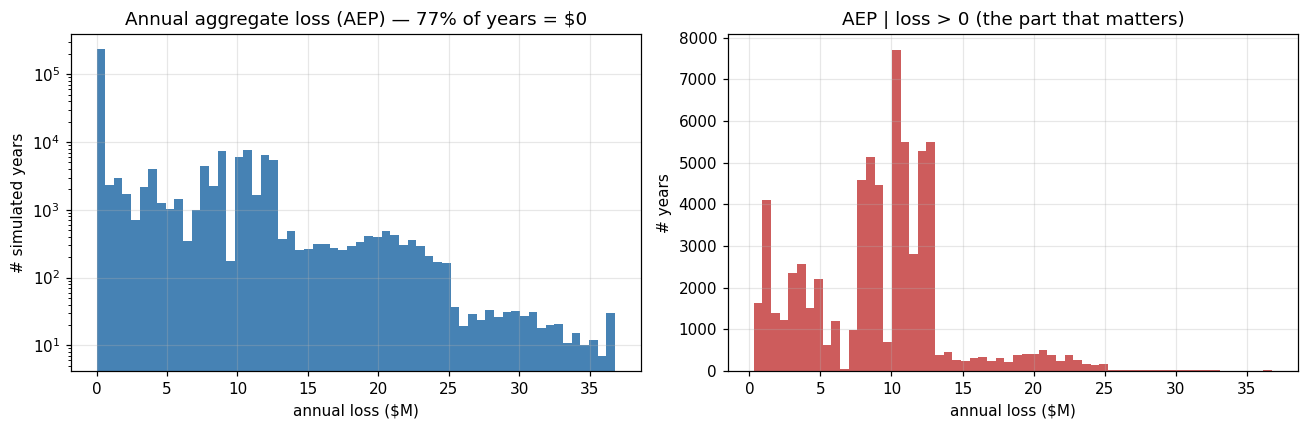

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(aep / 1e6, bins=60, color="steelblue")
ax[0].set(title=f"Annual aggregate loss (AEP) — {100*(aep==0).mean():.0f}% of years = $0",
          xlabel="annual loss ($M)", ylabel="# simulated years"); ax[0].set_yscale("log")
nz = aep[aep > 0]
ax[1].hist(nz / 1e6, bins=60, color="indianred")
ax[1].set(title="AEP | loss > 0 (the part that matters)", xlabel="annual loss ($M)", ylabel="# years")
plt.tight_layout(); plt.show()

## 5 · Read the risk metrics off the annual vectors

AEP = annual aggregate (total); OEP = annual maximum single event. PML at return period *T* = the
(1−1/T) percentile. Each is shown both in **dollars** and as a **% of TIV** (Total Insured Value = the
asset value, $36.78M) — the % makes the severity legible at a glance and comparable across assets.

In [6]:
def metrics(aep, oep):
    var99 = np.quantile(aep, 0.99)
    return {
        "EAL": aep.mean(),
        "VaR95 (AEP-PML20)":   np.quantile(aep, 0.95),
        "VaR99 (AEP-PML100)":  var99,
        "VaR99.6 (AEP-PML250)": np.quantile(aep, 0.996),
        "TVaR99":              aep[aep >= var99].mean(),
        "OEP-PML100":          np.quantile(oep, 0.99),
        "zero_loss_fraction":  (aep == 0).mean(),
    }
M = metrics(aep, oep)
mt = pd.DataFrame([
    {"metric": k,
     "value": (f"{v:.1%}" if k == "zero_loss_fraction" else f"${v/1e6:,.2f}M"),
     "% of TIV": ("—" if k == "zero_loss_fraction" else f"{100*v/ASSET_VALUE:.1f}%")}
    for k, v in M.items()
])
print(f"TIV = ${ASSET_VALUE/1e6:.1f}M · λ_collection = {LAMBDA_COLLECTION}/yr (FITTED) · NegBin φ={FANO} "
      f"· metrics as $ and % of TIV (real, record-limited)")
mt

TIV = $36.8M · λ_collection = 29.6/yr (FITTED) · NegBin φ=3.37 · metrics as $ and % of TIV (real, record-limited)


,metric,value,% of TIV
0,EAL,$2.09M,5.7%
1,VaR95 (AEP-PML20),$12.16M,33.1%
2,VaR99 (AEP-PML100),$19.97M,54.3%
3,VaR99.6 (AEP-PML250),$22.73M,61.8%
4,TVaR99,$23.20M,63.1%
5,OEP-PML100,$12.52M,34.1%
6,zero_loss_fraction,77.2%,—


## 6 · The Method-0 contrast — why the old repo's tail was wrong

Method-0 replaces each year's stochastic outcome by its *expectation* (`λ_asset × E[loss]`), i.e. a constant
every year. It **preserves EAL** but its annual "distribution" is a spike at the mean → its VaR₉₉ ≈ EAL,
far below the true tail. The hit-or-miss variance — the thing the tail is made of — is gone.

In [7]:
method0_annual_expected = LAMBDA_COLLECTION * np.mean(p_evt * loss_evt)   # deterministic per-year contribution
print(f"Method-0 EAL              : ${method0_annual_expected:,.0f}   (matches MC EAL — mean is preserved)")
print(f"Method-0 'VaR99'          : ${method0_annual_expected:,.0f}   (= EAL — the annual loss is ~constant)")
print(f"CORRECT MC VaR99 (AEP-PML100): ${M['VaR99 (AEP-PML100)']:,.0f}")
ratio = M['VaR99 (AEP-PML100)'] / max(method0_annual_expected, 1)
print(f"→ Method-0 understates the 1-in-100 loss by ~{ratio:.0f}×. EAL agrees; the TAIL does not.")
print("  (Direction isn't universal — a fitted-then-capped Method-0 can instead saturate at asset value, the")
print("   old repo's failure. What's universal: it discards the hit/miss variance, so the tail is never right.)")

Method-0 EAL              : $2,088,380   (matches MC EAL — mean is preserved)
Method-0 'VaR99'          : $2,088,380   (= EAL — the annual loss is ~constant)
CORRECT MC VaR99 (AEP-PML100): $19,971,118
→ Method-0 understates the 1-in-100 loss by ~10×. EAL agrees; the TAIL does not.
  (Direction isn't universal — a fitted-then-capped Method-0 can instead saturate at asset value, the
   old repo's failure. What's universal: it discards the hit/miss variance, so the tail is never right.)


## 7 · Poisson vs Negative Binomial — the over-dispersion payoff (DD-2)

Same `λ`, same severities — only the **count distribution** differs. NegBin's year-to-year clustering (the
fitted φ ≈ 3.4) leaves **EAL unchanged** but **fattens the tail**: VaR/PML rise. This is *why* DD-2 insisted
on testing dispersion rather than defaulting to Poisson — Poisson would under-state the very return periods
the model exists to price.

In [8]:
def _row(name, a, o):
    v99, v996 = np.quantile(a, 0.99), np.quantile(a, 0.996)
    return {"count model": name, "zero-loss yrs": f"{100*(a==0).mean():.0f}%", "EAL": f"${a.mean()/1e6:.2f}M",
            "VaR99 (PML100)": f"${v99/1e6:.2f}M ({100*v99/ASSET_VALUE:.0f}%)",
            "VaR99.6 (PML250)": f"${v996/1e6:.2f}M ({100*v996/ASSET_VALUE:.0f}%)",
            "OEP-PML100": f"${np.quantile(o,0.99)/1e6:.2f}M"}
print(f"Poisson vs NegBin (φ={FANO}) — same EAL, fatter NegBin tail (the DD-2 payoff):")
pd.DataFrame([_row("Poisson (φ=1)", aep_p, oep_p), _row(f"NegBin (φ={FANO}) — used", aep, oep)])

Poisson vs NegBin (φ=3.37) — same EAL, fatter NegBin tail (the DD-2 payoff):


,count model,zero-loss yrs,EAL,VaR99 (PML100),VaR99.6 (PML250),OEP-PML100
0,Poisson (φ=1),77%,$2.09M,$19.62M (53%),$22.62M (61%),$12.52M
1,NegBin (φ=3.37) — used,77%,$2.09M,$19.97M (54%),$22.73M (62%),$12.52M


## 8 · Persist the M4 artifacts → `data/hail/`

In [9]:
out = ROOT / "data" / "hail"
pd.DataFrame({"sim_year": np.arange(N_YEARS), "aep_usd": aep, "oep_usd": oep}) \
    .to_parquet(out / "hayhurst_hail_m4_annual_vectors.parquet", index=False)
summary = {
    "layer": "M4_loss_metrics", "peril": "HAIL", "asset": "Hayhurst Texas Solar", "asset_value_usd": ASSET_VALUE,
    "engine": "compound-Poisson Monte Carlo, event-level thinning, Negative-Binomial counts (Gamma-Poisson)",
    "n_sim_years": N_YEARS,
    "lambda_collection_per_yr": LAMBDA_COLLECTION,
    "lambda_collection_status": "FITTED on the ~5.65-yr MRMS record (DD-3 Stage 1) — real, record-limited (not illustrative)",
    "count_model": "negative_binomial", "fano_factor": FANO,
    "lambda_asset_per_yr": round(lam_asset, 4), "loss_basis": "gross physical only (no financial terms / BI — §9 deferred)",
    "metrics_usd": {k: round(float(v), 2) for k, v in M.items() if k != "zero_loss_fraction"},
    "metrics_pct_of_tiv": {k: round(100 * float(v) / ASSET_VALUE, 1) for k, v in M.items() if k != "zero_loss_fraction"},
    "tiv_usd": ASSET_VALUE,
    "zero_loss_fraction": round(float(M["zero_loss_fraction"]), 4),
    "metrics_status": "real but RECORD-LIMITED (~5.65 yr; deep tail needs longer record + EVT — DD-3 Stage 2)",
    "known_answer_checks": "pass (EAL≈analytic both; Poisson zero≈exp(−λ_asset); NegBin zero>Poisson; AEP≥OEP)",
    "provenance": {"plan": "docs/plans/hail/phase-5-loss-metrics.md", "from": "hayhurst_hail_m3_damage.parquet"},
}
(out / "hayhurst_hail_m4_metrics.json").write_text(json.dumps(summary, indent=2))
print(f"M4 annual vectors: {N_YEARS:,} years → {out/'hayhurst_hail_m4_annual_vectors.parquet'}")
print(f"M4 metrics:                  → {out/'hayhurst_hail_m4_metrics.json'}")

M4 annual vectors: 300,000 years → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m4_annual_vectors.parquet
M4 metrics:                  → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m4_metrics.json


## Findings — and the M0→M4 skeleton is complete

- **The engine is correct and verified.** Compound-Poisson MC with event-level thinning, the LOTV rule
  enforced (`Bernoulli(pᵢ)` + full loss, never `pᵢ × loss`), capped per simulated year. Known-answer checks
  pass; the Method-0 contrast shows the old shortcut understates the 1-in-100 loss by ~order(s) of magnitude
  while agreeing on EAL — the exact failure this rebuild exists to fix.
- **The metrics are now real (record-limited).** `λ_collection` is **fitted** on the ~5.65-yr record and
  the counts are over-dispersed → **NegBin** (DD-2 confirmed; the Poisson-vs-NegBin table shows the fatter
  tail). The distribution *body* is decent; the **deep tail still wants a longer record + EVT** — so these
  are *record-limited*, not illustrative.
- **End-to-end:** raw evidence (M0) → catalog (M1) → coupling (M2) → damage (M3) → **annual loss vectors →
  EAL/VaR/PML/TVaR (M4)**. The whole M0→M4 spine now runs, the right way, on a real ~5.65-yr fit.
- **Production path from here:** the **NOAA-calibrated extension** (longer record → deeper, more credible
  tail — DD-3 Stage 2), an **EVT-GPD tail** (§10), the **calibrated damage curve** (PV claims), and
  **financial terms** (deductibles/limits/BI — §9).